In [11]:
#load dataset

from tensorflow.keras.datasets import mnist 
(X_train , y_train) , (X_test , y_test) = mnist.load_data()

print(len(X_train))
print(len(X_test))

60000
10000


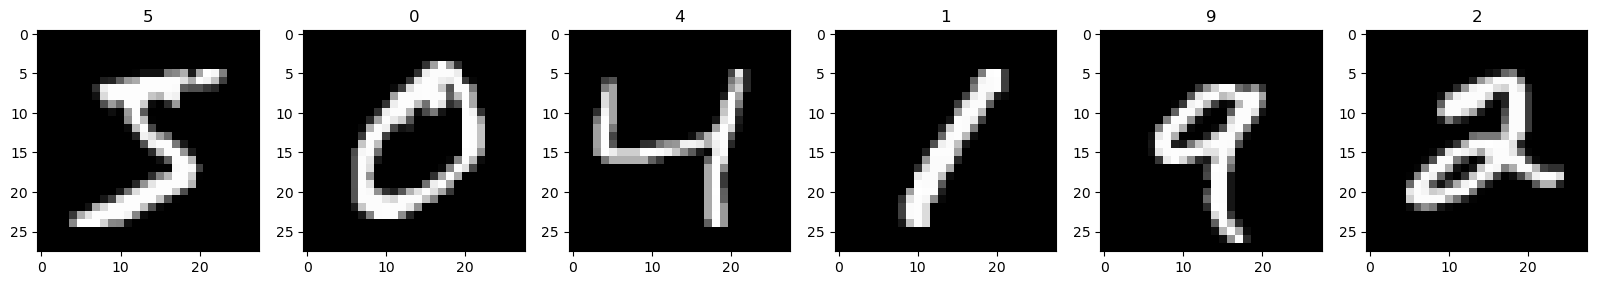

In [14]:
import matplotlib.pyplot as plt 
#%matplotlib inline
import matplotlib.cm as cm 
import numpy as np 


#plot first 6 trainnig image here 
fig = plt.figure(figsize=(20,20))
for i in range(6):
    ax = fig.add_subplot(1,6 , i+1 )
    ax.imshow(X_train[i] , cmap='gray')
    ax.set_title(str(y_train[i]))

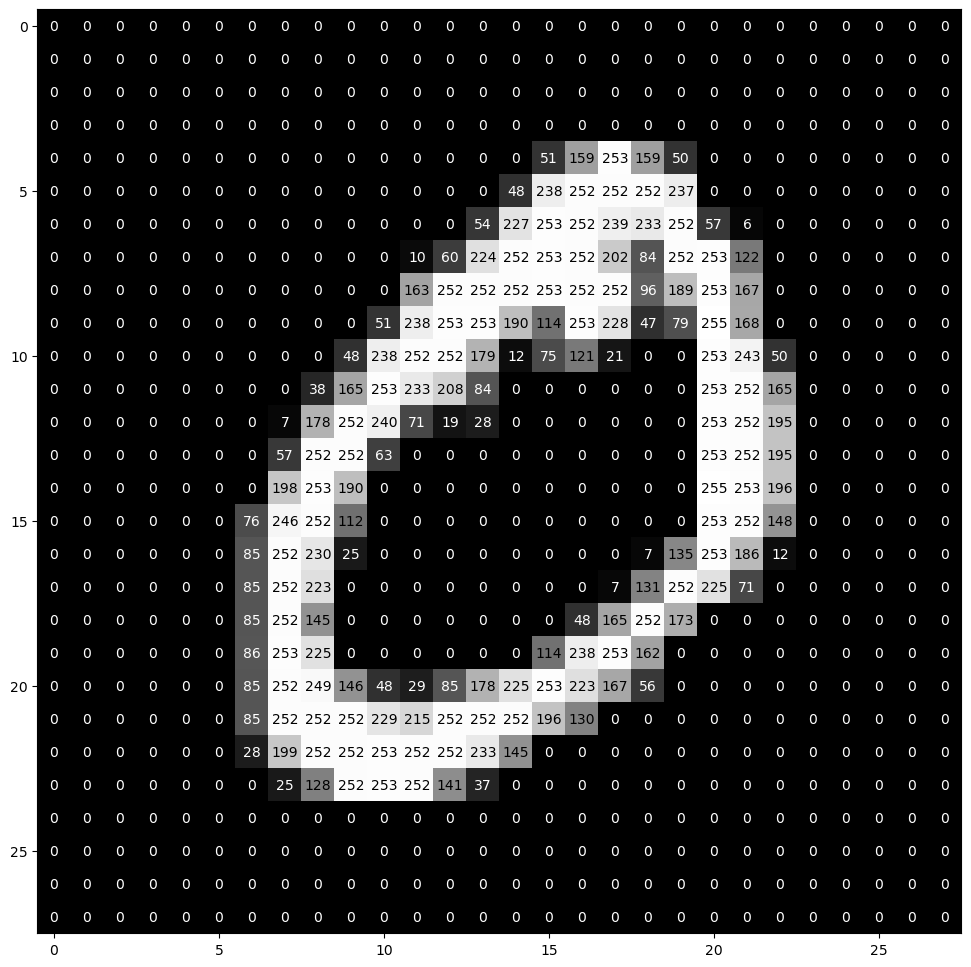

In [22]:
def visualize_input(img, ax):
    ax.imshow(img, cmap='gray')
    width, height = img.shape
    thresh = img.max()/2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(round(img[x][y],2)), xy=(y,x),
                        horizontalalignment='center',
                        verticalalignment='center',
                        color='white' if img[x][y]<thresh else 'black')

fig = plt.figure(figsize = (12,12))
ax = fig.add_subplot(111)
visualize_input(X_train[1], ax)

In [26]:
X_train=X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

print('X_train shape:', X_train.shape)
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 28, 28)
60000 train samples
10000 test samples


In [32]:
from tensorflow.keras.utils import to_categorical

num_classes= 10 

print(y_train[:10])

#one-hot coding 

y_train = to_categorical(y_train , num_classes)
y_test = to_categorical(y_test , num_classes)

print(y_train[:10])


[5 0 4 1 9 2 1 3 1 4]
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [ ]:
img_rows , img_cols = 28,28

X_train = X_train.reshape(X_train.shape[0] , img_rows , img_cols , 1)
X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)

print('input_shape: ', input_shape)
print('x_train shape:', X_train.shape)   

input_shape:  (28, 28, 1)
x_train shape: (60000, 28, 28, 1)


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Dense , Dropout , GlobalAveragePooling2D

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3) , padding='same' , activation='relu' , input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()








Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'rmsprop',
    metrics=['accuracy']
)

In [49]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpointer = ModelCheckpoint(filepath='model.best.keras',verbose=1,save_best_only=True)

hist = model.fit(X_train , y_train , batch_size=64 , epochs=10 , validation_data=(X_test , y_test) , callbacks=[checkpointer],verbose=2,shuffle=True)

Epoch 1/10

Epoch 1: val_loss improved from None to 2.30105, saving model to model.best.keras

Epoch 1: finished saving model to model.best.keras
938/938 - 11s - 12ms/step - accuracy: 0.1114 - loss: 2.3016 - val_accuracy: 0.1135 - val_loss: 2.3010
Epoch 2/10

Epoch 2: val_loss did not improve from 2.30105
938/938 - 10s - 11ms/step - accuracy: 0.1124 - loss: 2.3014 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 3/10

Epoch 3: val_loss did not improve from 2.30105
938/938 - 10s - 11ms/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1135 - val_loss: 2.3011
Epoch 4/10

Epoch 4: val_loss did not improve from 2.30105
938/938 - 10s - 11ms/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1135 - val_loss: 2.3011
Epoch 5/10

Epoch 5: val_loss improved from 2.30105 to 2.30101, saving model to model.best.keras

Epoch 5: finished saving model to model.best.keras
938/938 - 10s - 11ms/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1135 - val_loss: 2.3010
Epoch 6/10

Epoch 

In [ ]:
model.load_weights('model.best.keras')


model.best.keras


In [59]:
score = model.evaluate(X_test, y_test , verbose=0)
#accuracy=100*score[1]
print('Test accuracy: ' ,score[1])

Test accuracy:  0.11349999904632568
